In [1]:
# %%
# --- Cella 1: Import e Parametri ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Parametri che puoi cambiare
RISOLUZIONE = '10min' # Risoluzione (es. '10min', 'H')
TAU_ORE = 6.0         # Tempo di decadimento impulsi (in ore)

# Periodo di analisi (Marzo-Aprile)
START_DATE = '2021-03-01 00:00:00+00:00'
END_DATE = '2021-05-01 00:00:00+00:00'

print("Librerie e parametri caricati.")

Librerie e parametri caricati.


Cella 2: Caricamento e Creazione del "FONDO" (df_agg)
Questo carica il file da 3.7M, lo pulisce, lo filtra e crea df_agg (il fondo).

In [2]:
# %%
# --- Cella 2: Creazione del "FONDO" (dal file 3.7M) ---

file_fondo = r"C:\Users\rauso\Desktop\tesi\dataset 3.7M righe\doge_tweets_1.1.21-4.30.21.csv"
colonne_da_usare = ['created_at', 'tweet']

try:
    print(f"Caricamento file 'fondo' ({file_fondo})...")
    print("(Uso 'engine=python', potrebbe richiedere qualche minuto...)")
    df_fondo_raw = pd.read_csv(
        file_fondo,
        usecols=colonne_da_usare,
        index_col='created_at', # Carica come indice (stringa)
        engine='python',
        on_bad_lines='skip'
    )
except FileNotFoundError:
    print(f"ERRORE: File '{file_fondo}' non trovato.")
    assert False
except Exception as e:
    print(f"ERRORE: {e}")

print("File 'fondo' caricato. Avvio pulizia e conversione date...")
# 1. Converti indice in datetime (Metodo Robusto)
df_fondo_raw.index = pd.to_datetime(df_fondo_raw.index, errors='coerce')
df_fondo_raw = df_fondo_raw[df_fondo_raw.index.notna()] # Rimuovi date fallite
if df_fondo_raw.index.tz is None:
    df_fondo_raw.index = df_fondo_raw.index.tz_localize('UTC')
else:
    df_fondo_raw.index = df_fondo_raw.index.tz_convert('UTC')

# 2. Rimuovi Retweet
df_fondo_pulito = df_fondo_raw[~df_fondo_raw['tweet'].astype(str).str.startswith('RT @')]

# 3. Ordina l'indice (FONDAMENTALE)
df_fondo_pulito = df_fondo_pulito.sort_index()

# 4. Filtra per il periodo (Marzo-Aprile)
df_fondo_filtrato = df_fondo_pulito.loc[START_DATE:END_DATE]
print(f"Fondo filtrato (Mar-Apr): {len(df_fondo_filtrato)} tweet.")

# 5. Aggrega e Normalizza
print(f"Aggregazione 'fondo' a {RISOLUZIONE}...")
df_agg = df_fondo_filtrato['tweet'].resample(RISOLUZIONE).size().to_frame(name='conteggio_tweet')
df_agg = df_agg.fillna(0)
scaler_fondo = StandardScaler()
df_agg['n_fondo'] = scaler_fondo.fit_transform(df_agg[['conteggio_tweet']])

print("Creazione 'df_agg' (fondo) completata.")
print(df_agg.head())

Caricamento file 'fondo' (C:\Users\rauso\Desktop\tesi\dataset 3.7M righe\doge_tweets_1.1.21-4.30.21.csv)...
(Uso 'engine=python', potrebbe richiedere qualche minuto...)
File 'fondo' caricato. Avvio pulizia e conversione date...
Fondo filtrato (Mar-Apr): 1766684 tweet.
Aggregazione 'fondo' a 10min...
Creazione 'df_agg' (fondo) completata.
                           conteggio_tweet   n_fondo
created_at                                          
2021-03-01 00:00:00+00:00               70 -0.355819
2021-03-01 00:10:00+00:00               68 -0.360978
2021-03-01 00:20:00+00:00               70 -0.355819
2021-03-01 00:30:00+00:00               71 -0.353239
2021-03-01 00:40:00+00:00               80 -0.330024


In [3]:
# %%
# --- Cella 3: Creazione degli "IMPULSI" (da all_musk_posts.csv) ---

file_musk = r"C:\Users\rauso\Desktop\tesi\archive (2)\all_musk_posts.csv"
colonne_musk = ['createdAt', 'fullText', 'likeCount', 'retweetCount']

try:
    print(f"\nCaricamento file 'musk' ({file_musk})...")
    df_musk_raw = pd.read_csv(file_musk, usecols=colonne_musk, low_memory=False)
except FileNotFoundError:
    print(f"ERRORE: File '{file_musk}' non trovato.")
    assert False

print("File 'musk' caricato. Avvio pulizia e conversione date...")
# 1. Rimuovi Retweet
df_musk_pulito = df_musk_raw[~df_musk_raw['fullText'].astype(str).str.startswith('RT @')].copy()

# 2. Converti timestamp
df_musk_pulito['createdAt'] = pd.to_datetime(df_musk_pulito['createdAt'], utc=True, errors='coerce')
df_musk_pulito = df_musk_pulito.dropna(subset=['createdAt'])
df_musk_pulito = df_musk_pulito.set_index('createdAt')

# 3. Ordina e Filtra (Marzo-Aprile)
df_musk_pulito = df_musk_pulito.sort_index()
df_musk = df_musk_pulito.loc[START_DATE:END_DATE].copy()

# 4. Rinomina colonne per coerenza
df_musk = df_musk.rename(columns={
    'fullText': 'tweet',
    'likeCount': 'likes_count',
    'retweetCount': 'retweets_count'
})

print(f"Creazione 'df_musk' (impulsi) completata. Trovati {len(df_musk)} tweet.")


Caricamento file 'musk' (C:\Users\rauso\Desktop\tesi\archive (2)\all_musk_posts.csv)...


File 'musk' caricato. Avvio pulizia e conversione date...
Creazione 'df_musk' (impulsi) completata. Trovati 473 tweet.


In [4]:
# %%
# --- Cella 4: Calcolo Impulsi (Filtro per Rilevanza) ---

# 1. Calcola engagement
df_musk['engagement'] = df_musk['likes_count'].fillna(0) + df_musk['retweets_count'].fillna(0)

# 2. Filtra per Rilevanza
keywords = [
    'doge', 'dogecoin', 'shiba',    # Doge
    'moon', 'hodl', 'dogefather', # Slang
    'bitcoin', 'btc', 'crypto'   # Altre crypto
]
keyword_regex = '|'.join(keywords)
is_relevant = df_musk['tweet'].str.contains(keyword_regex, case=False, na=False)
df_musk['sentiment'] = np.where(is_relevant, 1, 0)
print(f"Trovati {df_musk['sentiment'].sum()} tweet rilevanti (su {len(df_musk)} totali).")

# 3. Calcola Ampiezza (con MinMaxScaler)
scaler_impulsi = MinMaxScaler() 
df_musk['ampiezza'] = scaler_impulsi.fit_transform(df_musk[['engagement']])

# 4. Calcola Valore Impulso
df_musk['impulso_valore'] = df_musk['ampiezza'] * df_musk['sentiment']

print("Calcolo impulsi completato.")

Trovati 34 tweet rilevanti (su 473 totali).
Calcolo impulsi completato.


In [5]:
# %%
# --- Cella 5: Costruzione n(t) Finale ---

n_t = df_agg['n_fondo'].copy()
print("Avvio costruzione n(t): applicazione impulsi al fondo...")

for t_tweet, riga in df_musk.iterrows():
    valore_impulso = riga['impulso_valore']
    if valore_impulso == 0:
        continue
    
    delta_t_secondi = (n_t.index - t_tweet).total_seconds()
    delta_t_ore = pd.Series(delta_t_secondi / 3600.0, index=n_t.index)
    delta_t_ore_positivo = delta_t_ore.mask(delta_t_ore < 0, np.nan)
    impulso_decay = valore_impulso * np.exp(-delta_t_ore_positivo / TAU_ORE)
    n_t = n_t.add(impulso_decay, fill_value=0)

df_agg['n_t_finale'] = n_t
print("Serie n(t) finale calcolata.")

Avvio costruzione n(t): applicazione impulsi al fondo...
Serie n(t) finale calcolata.


Generazione grafico di n(t)...
Focalizzazione grafico sul picco 14-20 Aprile 2021.


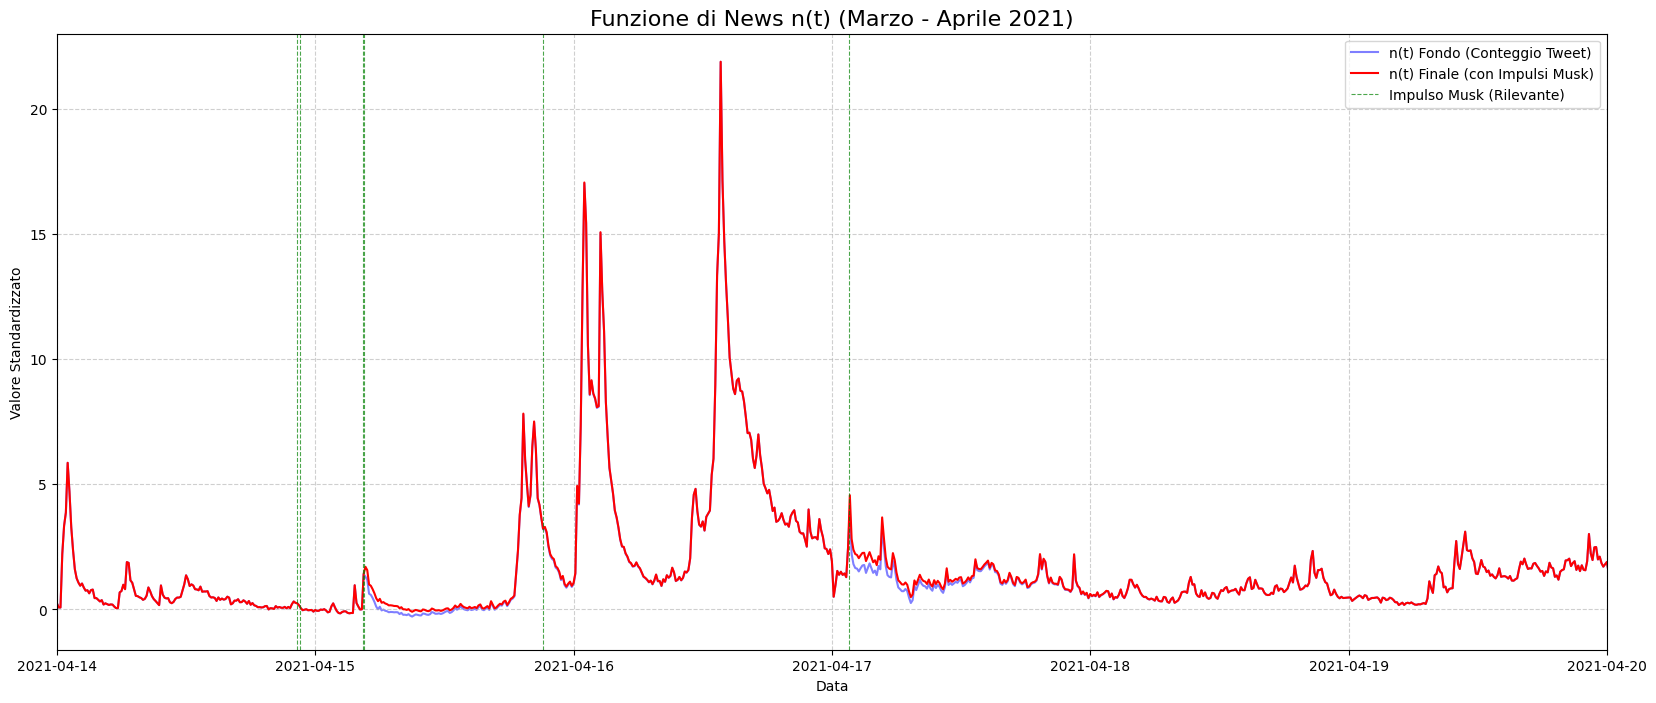

Grafico dell'intero periodo Marzo-Aprile...


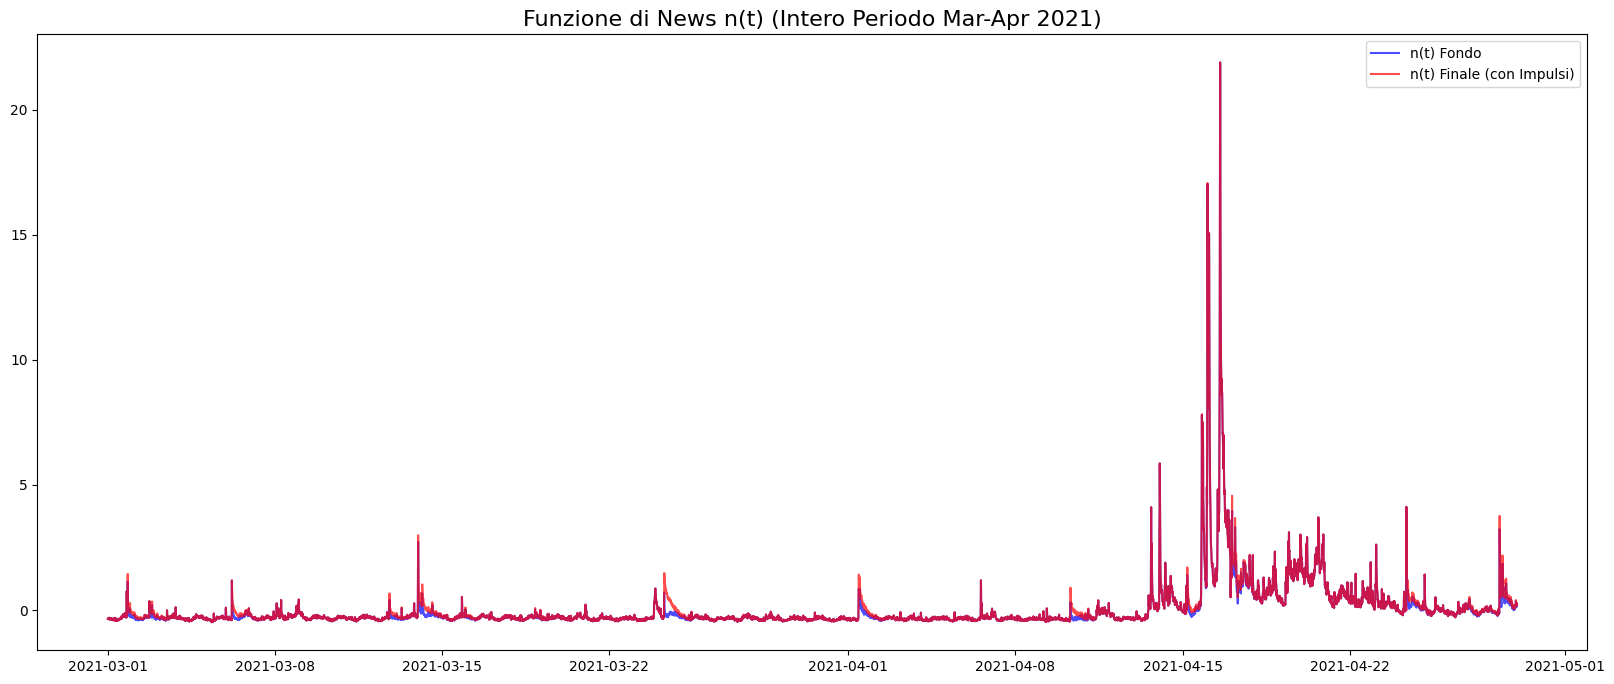

In [6]:
# %%
# --- Cella 6: Verifica Grafica ---

print("Generazione grafico di n(t)...")
plt.figure(figsize=(20, 8)) 

plt.plot(df_agg.index, df_agg['n_fondo'], label='n(t) Fondo (Conteggio Tweet)', color='blue', alpha=0.5, zorder=1)
plt.plot(df_agg.index, df_agg['n_t_finale'], label='n(t) Finale (con Impulsi Musk)', color='red', zorder=2)

tweet_rilevanti = df_musk[df_musk['impulso_valore'] > 0].index
for t_tweet in tweet_rilevanti:
    plt.axvline(t_tweet, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
if len(tweet_rilevanti) > 0:
    plt.axvline(tweet_rilevanti[0], color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='Impulso Musk (Rilevante)')

plt.legend()
plt.title('Funzione di News n(t) (Marzo - Aprile 2021)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Valore Standardizzato')
plt.grid(True, linestyle='--', alpha=0.6)

print("Focalizzazione grafico sul picco 14-20 Aprile 2021.")
plt.xlim([pd.to_datetime('2021-04-14'), pd.to_datetime('2021-04-20')])

plt.show()

# %%
# (Opzionale) Plotta l'intero periodo Mar-Apr
print("Grafico dell'intero periodo Marzo-Aprile...")
plt.figure(figsize=(20, 8)) 
plt.plot(df_agg.index, df_agg['n_fondo'], label='n(t) Fondo', color='blue', alpha=0.7)
plt.plot(df_agg.index, df_agg['n_t_finale'], label='n(t) Finale (con Impulsi)', color='red', alpha=0.7)
plt.legend()
plt.title('Funzione di News n(t) (Intero Periodo Mar-Apr 2021)', fontsize=16)
plt.show()

In [7]:
# --- Cella 6: Salvataggio della Funzione n(t) Finale ---

# Selezioniamo solo le colonne che ci servono per il modello ABM
colonne_da_salvare = ['n_fondo', 'n_t_finale']

# Salviamo il file che la Cella 1 del Modello ABM cercherà di caricare
df_agg[colonne_da_salvare].to_csv('funzione_news_n(t)_FINALE.csv')

print("File 'funzione_news_n(t)_FINALE.csv' salvato. Ora puoi passare al Modello ABM.")

File 'funzione_news_n(t)_FINALE.csv' salvato. Ora puoi passare al Modello ABM.
